In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df_fraud =pd.read_csv('creditcard.csv')
print('--- First 5 Rows ---')
display(df_fraud.head())

class_counts = df_fraud['Class'].value_counts()
fraud_percentage = (class_counts[1] / len(df_fraud)) * 100
print(f'\nNon-Fraudulent Transactions: {class_counts[0]}')
print(f'Fraudulent Transactions: {class_counts[1]}')
print(f'Percentage of Fraudulent Transactions: {fraud_percentage:.4f}')

--- First 5 Rows ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Non-Fraudulent Transactions: 284315
Fraudulent Transactions: 492
Percentage of Fraudulent Transactions: 0.1727


### **1. Dataset Loading & Class Imbalance Analysis**
* **Data Inspection:** Loaded the credit card transactions dataset and reviewed its layout.
* **Imbalance Calculation:** Computed absolute counts and percentage distribution of the target variable (`Class`), highlighting that fraudulent transactions represent a haevily skewed, minor fraction of the overall dataset.

C:\Users\dell\AppData\Local\Temp\ipykernel_9280\2779199132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fraud, x='Class', y='Amount', palette='Set2')


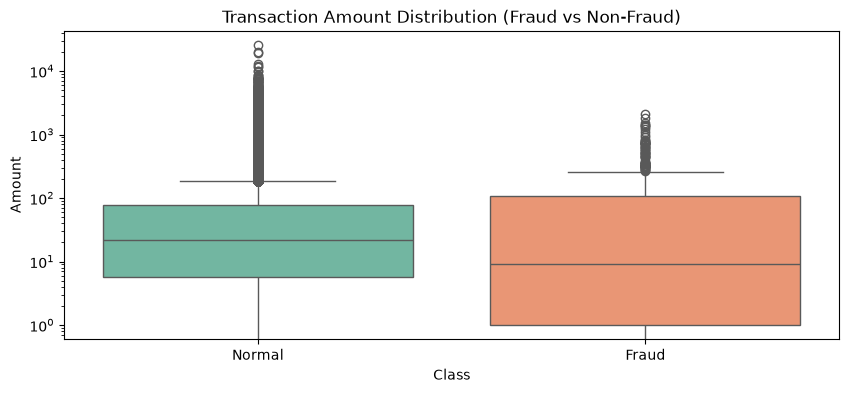

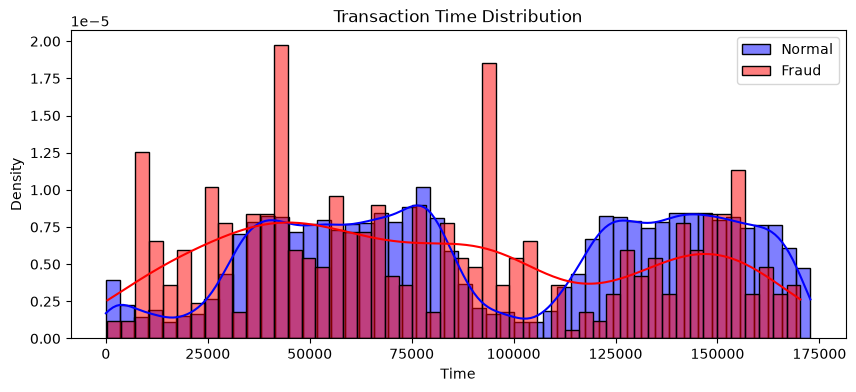

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_fraud, x='Class', y='Amount', palette='Set2')
plt.yscale('log')
plt.title('Transaction Amount Distribution (Fraud vs Non-Fraud)')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(df_fraud['Time'][df_fraud['Class'] == 0], bins=50, color='blue', label='Normal', kde=True, stat='density')
sns.histplot(df_fraud['Time'][df_fraud['Class'] == 1], bins=50, color='red', label='Fraud', kde=True, stat='density')
plt.title('Transaction Time Distribution')
plt.legend()
plt.show()

### **2. Exploratory Data Analysis (EDA)**
* **Amount Comparision:** Compared transaction amounts across fraudulent and non-fraudulent classes using box plot on a logarithmic scale.
* **Time Distribution:** Analyzed transaction timestamps to check behaivoral patterns and temporal spreads between normal and fraudulent events.

### **3. Why Standard Accuracy is Misleading**
* **The Accuracy Paradox:** In heavily imbalanced dataset (e.g., 99.8% normal vs 0.2% fraud), a naive model that predicts every single transaction as 'non-fraud' will automatically achieve an accuracy of 99.8%.
* **Operational Failure:** Such a model completely fails at its core objective-detecting actual fraud. Therefore, metrics like Precision, Recall, F1-Score, and AUC_ROC are essential instead of standard accuracy.

In [10]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from imblearn.over_sampling import SMOTE
x = df_fraud.drop('Class', axis=1)
y =df_fraud['Class']
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)
print(f'Resampled dataset shape: {x_resampled.shape}')
print(f'Resampled class distribution:\n{y_resampled.value_counts()}')

Resampled dataset shape: (568630, 30)
Resampled class distribution:
Class
0    284315
1    284315
Name: count, dtype: int64


### **4. Class Imbalance Handling via SMOTE**
* **Oversampling Technique:** Implemented Synthetic Minority Over-sampling Technique (`SMOTE`) to synthetically generate instances of the minority class (fraud).
* **Balanced Corpus:** Balanced the training feature space to prevent models from being biased toward the minority non-fraud class.

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
print(f'Training set shape: {x_train.shape}')
print(f'Testing set shape: {x_test.shape}')

Training set shape: (454904, 30)
Testing set shape: (113726, 30)


### **5. Stratified Train/Test Split**
* **Data Partitioning:** Split the balanced dataset into an 80% training set and a 20% testing set.
* **Stratification:** Maintained strict proportional class balance across subsets via `stratify=y_resampled`.

Training Models with class_weight='balanced'...


c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Models trained instantly!

================ Logistic Regression ================
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962

AUC-ROC Score: 0.9727

================ Random Forest ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.9433


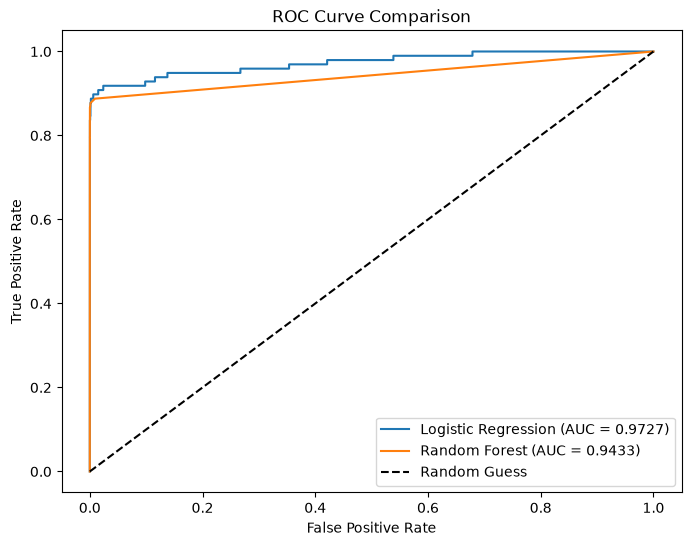

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Direct Train/Test Split (Bina SMOTE ke, original data par)
x = df_fraud.drop('Class', axis=1)
y = df_fraud['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Training Models with class_weight='balanced'...")

# 2. Logistic Regression with class_weight='balanced'
lr_model = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1)
lr_model.fit(x_train, y_train)

# 3. Fast Random Forest with class_weight='balanced' (n_estimators=15)
rf_model = RandomForestClassifier(n_estimators=15, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train)

print("Models trained instantly!")

# 4. Evaluation & ROC Curves
models = {'Logistic Regression': lr_model, 'Random Forest': rf_model}

plt.figure(figsize=(8, 6))
for name, model in models.items():
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)[:, 1]
    
    print(f"\n================ {name} ================")
    print(classification_report(y_test, preds))
    print(f"AUC-ROC Score: {roc_auc_score(y_test, probs):.4f}")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### **6. Model Training & Evaluation (Logistic Regression & Random Forest)**
* **Model Training:** Trained a `LogisticRegression` model (with increased iterations for convergence) and an optimized `RandomForestClassifier` utilizing class balancing weights to handle dataset skewness efficiently.
* **Performance Metrics:** Evaluated both models using precision, recall, F1-scores, and Area Under the ROC Curve (`AUC-ROC`) to ensure reliable classification performance beyond standard accuracy.
* **Comparative Insights:** Visualized comparative ROC curves to analyze true positive rates against false positive rates across decision thresholds.

### **7. Metric Importance: Recall vs. Precision Trade-Off**
* **Why Recall Matters Most:** In fraud detection, missing a fraudulent transaction (False Negative) leads to direct financial loss. Therefore, **Recall** is critical to ensure maximum actual frauds are successfully caught.
* **The Precision Balance:** While maximizing recall, maintaining reasonable **Precision** is important to prevent an excess of False Positives (blocking legitimate user transactions), which causes customer friction.

C:\Users\dell\AppData\Local\Temp\ipykernel_9280\805177681.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature', palette='viridis')


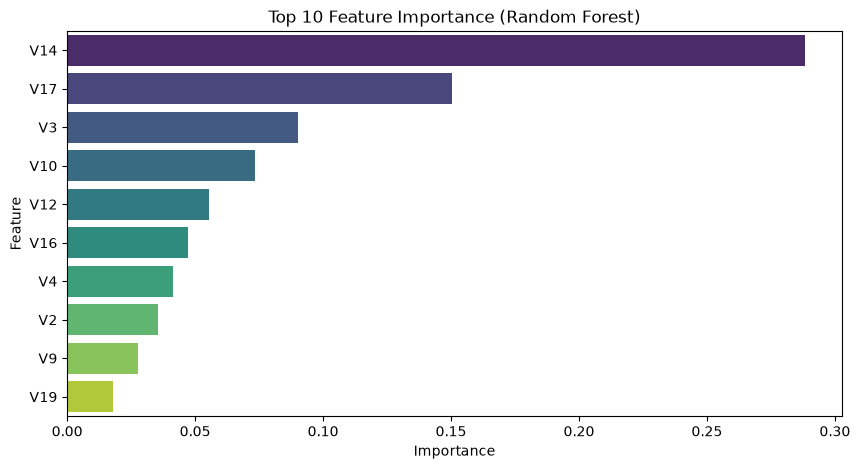

In [14]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.show()

### **8. Feature Importance Analysis**
* **Key Drivers:** Extracted feature importance weights from the trained Random Forest model to determine which transaction parameter and attribute most heavily to fraud prediction.

### **9. Scalability Discussion (1 Million Transactions/Hours)**
* **Real-Time Streaming Architecture:** To handle a high throughput of 1 million transactions per hour (~278 transactions per second), traditional batch inference is insufficient. A distributed stream processing framework like Apache Kafka combined with Apache Spark Streaming or Apache Flink is required.
* **Model Optimization:** Lightweight models (such as linear models or pruned gradient boosting models deployed via ONNX or TensorRT) should be containerized using Docker/Kubernetes on scalable cloud endpoints for low-latency scoring.